General Solution:
             ⎛        __________⎞          ⎛       __________⎞ 
             ⎜       ╱        2 ⎟          ⎜      ╱        2 ⎟ 
           x⋅⎝-u + ╲╱  4⋅D + u  ⎠       -x⋅⎝u + ╲╱  4⋅D + u  ⎠ 
           ──────────────────────       ───────────────────────
                    2⋅D                           2⋅D          
φ(x) = C₁⋅ℯ                       + C₂⋅ℯ                       


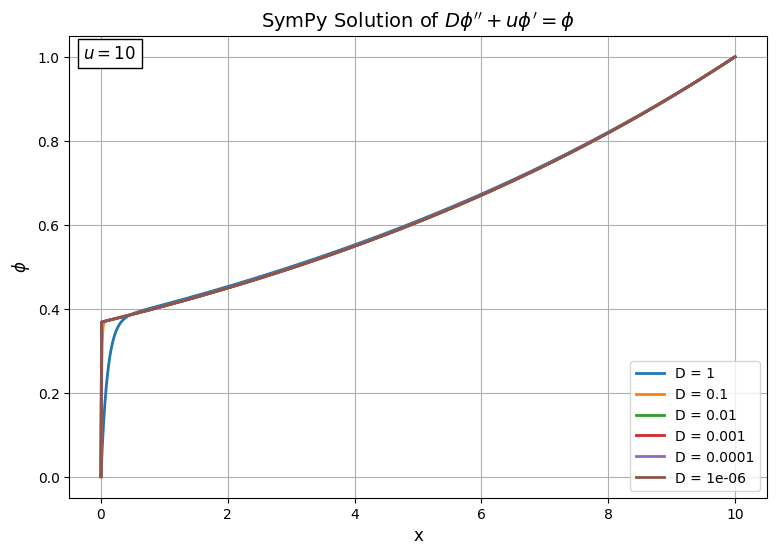

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Symbols
# ---------------------------------
x = sp.symbols('x', real=True)
D = sp.symbols('D', positive=True)
u = sp.symbols('u', real=True)

phi = sp.Function('phi')

# ---------------------------------
# Parameters (same as FiPy)
# ---------------------------------
L = 10
u_value = 10

D_values = [1.0, 0.1, 0.01, 0.001, 1e-4, 1e-6]

# ---------------------------------
# Define ODE
# D*phi'' + u*phi' = phi
# ---------------------------------
ode = sp.Eq(
    D * sp.diff(phi(x), x, 2)
    + u * sp.diff(phi(x), x)
    - phi(x),
    0
)

# ---------------------------------
# General symbolic solution
# ---------------------------------
general_solution = sp.dsolve(ode)

print("General Solution:")
sp.pprint(general_solution)

# ---------------------------------
# Plot
# ---------------------------------
plt.figure(figsize=(9,6))

x_vals = np.linspace(0, L, 1000)

for D_value in D_values:

    # Solution expression
    sol = general_solution.rhs

    # Unknown constants
    C1, C2 = sp.symbols('C1 C2')

    # Boundary conditions
    eq1 = sp.Eq(sol.subs(x, 0), 0)
    eq2 = sp.Eq(sol.subs(x, L), 1)

    constants = sp.solve(
        [eq1, eq2],
        [C1, C2],
        dict=True
    )[0]

    # Final symbolic solution
    phi_exact = sol.subs(constants)

    # Substitute numerical parameters
    phi_exact = phi_exact.subs({
        D: D_value,
        u: u_value
    })

    # Convert to numerical function
    phi_fun = sp.lambdify(x, phi_exact, "numpy")

    # Evaluate
    y = phi_fun(x_vals)

    plt.plot(
        x_vals,
        y,
        linewidth=2,
        label=f"D = {D_value:g}"
    )

plt.legend()

plt.xlabel("x", fontsize=12)
plt.ylabel(r"$\phi$", fontsize=12)
plt.title(r"SymPy Solution of $D\phi'' + u\phi' = \phi$", fontsize=14)

plt.grid(True)
plt.legend()

# Display u on the graph
plt.text(
    0.02, 0.95,
    rf"$u = {u_value}$",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='black')
)

# # Display u on the graph
# plt.text(
#     0.12, 0.95,
#     rf"$L = {L}$",
#     transform=plt.gca().transAxes,
#     fontsize=12,
#     bbox=dict(facecolor='white', edgecolor='black')
# )


plt.show()

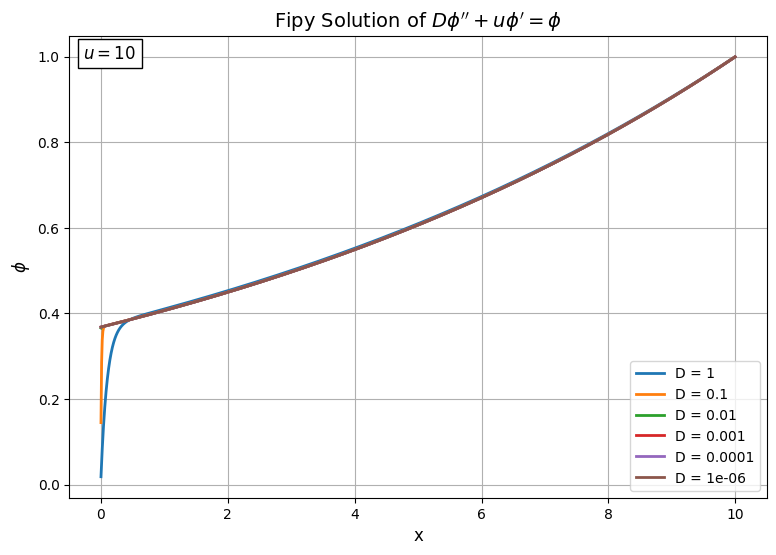

In [42]:
from fipy import (
    CellVariable,
    Grid1D,
    DiffusionTerm,
    PowerLawConvectionTerm,
    ImplicitSourceTerm,
    DefaultAsymmetricSolver
)

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------
# Mesh
# ---------------------------------
L = 10.0
nx = 1000
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

# ---------------------------------
# Parameters
# ---------------------------------
u = 10
convCoeff = (u,)

# Try different diffusion coefficients
D_values = [1.0, 0.1, 0.01, 0.001, 1e-4, 1e-6]

plt.figure(figsize=(9,6))

for D in D_values:

    # -----------------------------
    # Variable
    # -----------------------------
    phi = CellVariable(
        name="phi",
        mesh=mesh,
        value=0.0
    )

    # -----------------------------
    # Boundary Conditions
    # -----------------------------
    phi.constrain(0.0, mesh.facesLeft)
    phi.constrain(1.0, mesh.facesRight)

    # -----------------------------
    # Equation
    # D*d²(phi)/dx² + u*d(phi)/dx = phi
    # -----------------------------
    eq = (
        DiffusionTerm(coeff=D)
        + PowerLawConvectionTerm(coeff=convCoeff)
        - ImplicitSourceTerm(coeff=1.0)
    )

    # -----------------------------
    # Solve
    # -----------------------------
    eq.solve(
        var=phi,
        solver=DefaultAsymmetricSolver(
            tolerance=1e-15,
            iterations=5000
        )
    )

    # -----------------------------
    # Plot
    # -----------------------------
    x = mesh.cellCenters[0].value

    plt.plot(
        x,
        phi.value,
        linewidth=2,
        label=f"D = {D:g}"
    )

plt.xlabel("x", fontsize=12)
plt.ylabel(r"$\phi$", fontsize=12)
plt.title(r"Fipy Solution of $D\phi'' + u\phi' = \phi$", fontsize=14)
plt.text(
    0.02, 0.95,
    rf"$u = {u}$",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='black')
)


# # Display u on the graph
# plt.text(
#     0.12, 0.95,
#     rf"$L = {L}$",
#     transform=plt.gca().transAxes,
#     fontsize=12,
#     bbox=dict(facecolor='white', edgecolor='black')
# )


plt.grid(True)
plt.legend()



plt.show()

D = 1
Maximum Error = 4.991274e-04
L2 Error      = 2.323188e-04

D = 0.1
Maximum Error = 4.991274e-04
L2 Error      = 2.323188e-04

D = 0.01
Maximum Error = 4.991274e-04
L2 Error      = 2.323188e-04

D = 0.001
Maximum Error = 4.991274e-04
L2 Error      = 2.323188e-04

D = 0.0001
Maximum Error = 4.991274e-04
L2 Error      = 2.323188e-04

D = 1e-06
Maximum Error = 4.991274e-04
L2 Error      = 2.323188e-04



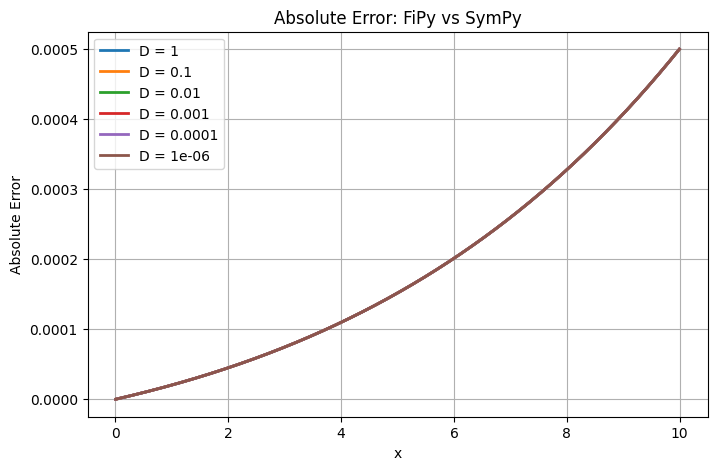

In [48]:
plt.figure(figsize=(8,5))

for D_value in D_values:

    # SymPy solution
    ...
    x_compare = mesh.cellCenters[0].value
    sympy_solution = phi_fun(x_compare)

    # FiPy solution
    ...
    fipy_solution = phi.value

    # Errors
    max_error = np.max(np.abs(fipy_solution - sympy_solution))
    l2_error = np.sqrt(np.mean((fipy_solution - sympy_solution)**2))

    print(f"D = {D_value:g}")
    print(f"Maximum Error = {max_error:.6e}")
    print(f"L2 Error      = {l2_error:.6e}\n")

    error = np.abs(fipy_solution - sympy_solution)

    plt.plot(
        x_compare,
        error,
        linewidth=2,
        label=f"D = {D_value:g}"
    )

plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.title("Absolute Error: FiPy vs SymPy")
plt.grid(True)
plt.legend()

plt.show()